Data loaded successfully.
Development Metrics Result:   metric metric_id model_family slice     value
0   GINI      gini           PD   VAL  0.556332
1    AUC   auc_roc           PD   VAL  0.778166
2     KS        ks           PD   VAL  0.432612
Validation Metrics Result:   metric metric_id model_family slice     value
0   GINI      gini           PD   VAL  0.558275
1    AUC   auc_roc           PD   VAL  0.779137
2     KS        ks           PD   VAL  0.439665


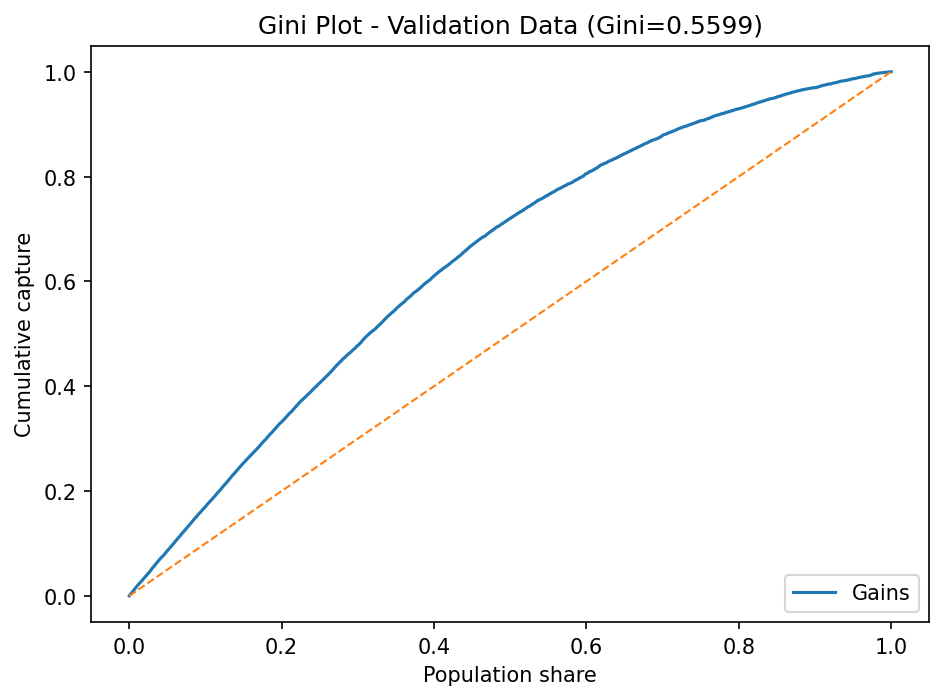

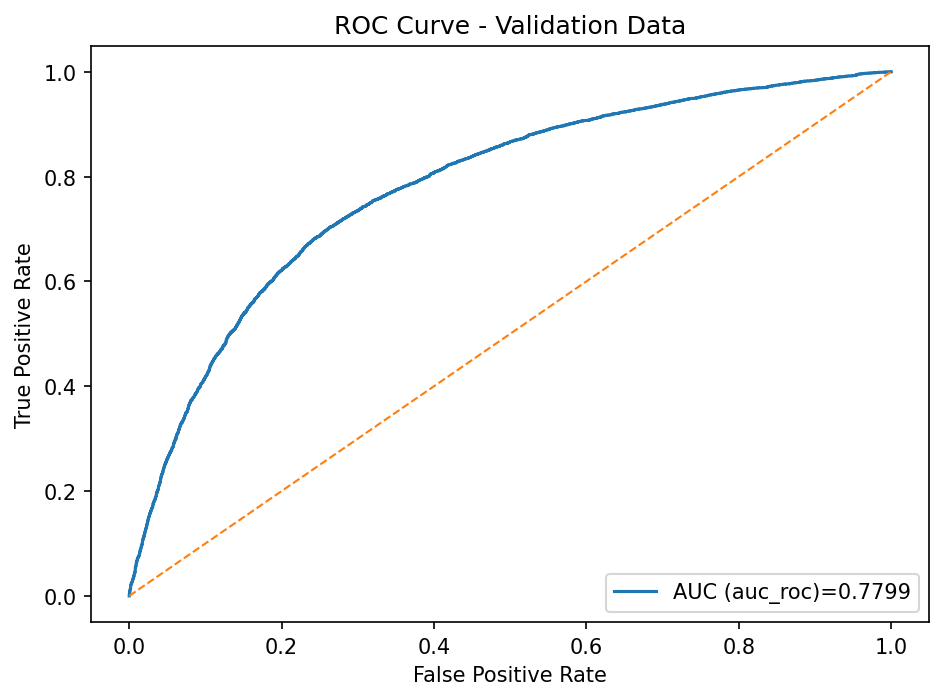

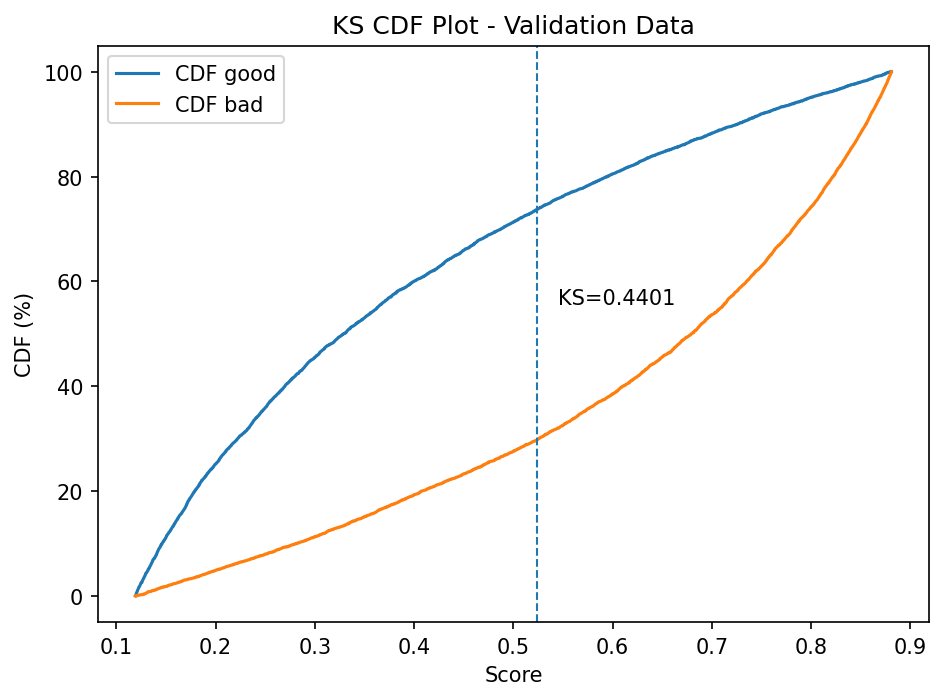

In [ ]:
import yaml
import pandas as pd
import matplotlib
from pathlib import Path
from IPython.display import Image, display
from risk_validation.core.metrics.impl import pd as pd_metrics  # noqa: F401
from risk_validation.core.services.pd.metrics_service import PDMetricsService
from risk_validation.core.utils.plots import plot_gini, plot_roc, plot_ks_cdf_with_maxgap
from risk_validation.core.utils.rag import rag_for_metric

# Setup data directory
DATA_DIR = Path('..') / 'data'
csv_path = DATA_DIR / 'sample.csv'

# Load data
try:
    df = pd.read_csv(csv_path)
    print("Data loaded successfully.")
except FileNotFoundError:
    raise ValueError(f"CSV not found at {csv_path}")

# Column mappings for PDMetricsService
params = {
    'y_col': 'default_flag',
    'p_col': 'pred_br',
    'score_col': 'score_pd',
    'period_col': 'QTR',
    'band_col': 'BAND'
}

# Initialize the PDMetricsService with the requested metrics
service = PDMetricsService(['gini', 'auc_roc', 'ks'])

# Filter datasets by the developmental and validation years
dev_year = 2019
val_year = 2020

df_dev = df[df['score_year'] == dev_year].copy()
df_val = df[df['score_year'] == val_year].copy()

# Compute metrics for developmental and validation datasets
try:
    dev_result = service.compute(df_dev, params)
    val_result = service.compute(df_val, params)

    # Ensure results contain values
    assert 'value' in dev_result.columns, "Compute error - 'value' column missing in dev results."
    assert 'value' in val_result.columns, "Compute error - 'value' column missing in val results."

except Exception as e:
    raise RuntimeError(f"Metric computation failed: {e}")

# Displaying the computed metrics
print("Development Metrics Result:", dev_result)
print("Validation Metrics Result:", val_result)

# Plotting Paths
plot_dir = Path('plots')
plot_dir.mkdir(exist_ok=True)

# Plot Gini
try:
    gini_plot_path = plot_gini(
        y_true=df_val['default_flag'],
        y_score=df_val['score_pd'],
        title='Gini Plot - Validation Data',
        out_path=plot_dir / 'gini_plot.png'
    )
    display(Image(filename=str(gini_plot_path)))
except Exception as e:
    print(f"Failed to plot Gini: {e}")

# Plot ROC
try:
    roc_plot_path = plot_roc(
        y_true=df_val['default_flag'],
        y_score=df_val['score_pd'],
        title='ROC Curve - Validation Data',
        out_path=plot_dir / 'roc.png'
    )
    display(Image(filename=str(roc_plot_path)))
except Exception as e:
    print(f"Failed to plot ROC: {e}")

# Plot KS
try:
    ks_plot_path, ks_table = plot_ks_cdf_with_maxgap(
        y_true=df_val['default_flag'],
        y_score=df_val['score_pd'],
        title='KS CDF Plot - Validation Data',
        out_path=plot_dir / 'ks_cdf.png'
    )
    display(Image(filename=str(ks_plot_path)))
except Exception as e:
    print(f"Failed to plot KS: {e}")